目录创建完成
使用text8数据集运行...
文本数据处理与词向量训练

步骤1: 加载数据集
正在下载text8数据集...
数据集加载完成，长度: 500000

步骤2: 文本预处理
预处理完成，清理后文本长度: 500000

步骤3: 构建词汇表
词汇表构建完成，词汇数量: 3654

前10个最常出现的词:
  1. 'the': 出现5022次
  2. 'of': 出现3047次
  3. 'and': 出现2369次
  4. 'in': 出现1913次
  5. 'to': 出现1804次
  6. 'one': 出现1632次
  7. 'a': 出现1511次
  8. 'is': 出现1099次
  9. 'that': 出现797次
  10. 'zero': 出现764次

步骤4: 转换为ID序列
ID序列转换完成，序列长度: 74437，未知词数量: 8713

步骤5: 二次采样处理
二次采样完成，原始序列长度: 74437, 采样后: 10083

步骤6: 训练Skip-gram模型
开始训练Skip-gram模型...
词汇表大小: 3654
训练样本数: 60486
词向量维度: 50
Epoch: 1/10, Batch: 100, Loss: 5.7079
Epoch: 1/10, Batch: 200, Loss: 5.6200
Epoch: 1/10, Batch: 300, Loss: 5.6196
Epoch: 1/10, Batch: 400, Loss: 5.6005
Epoch: 1/10, Batch: 500, Loss: 5.5772
Epoch: 1/10, Batch: 600, Loss: 5.5607
Epoch: 1/10, Batch: 700, Loss: 5.5306
Epoch: 1/10, Batch: 800, Loss: 5.4982
Epoch: 1/10, Batch: 900, Loss: 5.4735
Epoch: 1/10, Average Loss: 5.4603
Epoch: 2/10, Batch: 100, Loss: 4.9917
Epoch: 2/10, Batch: 200, Loss: 4.8917
Epoch: 2/10, Batch: 300, 

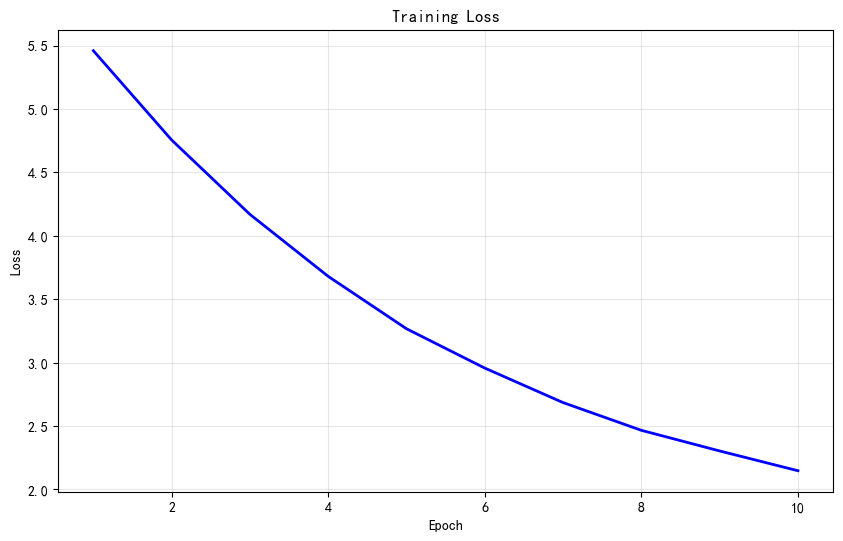


步骤7: 可视化词向量
正在使用TSNE进行降维可视化...


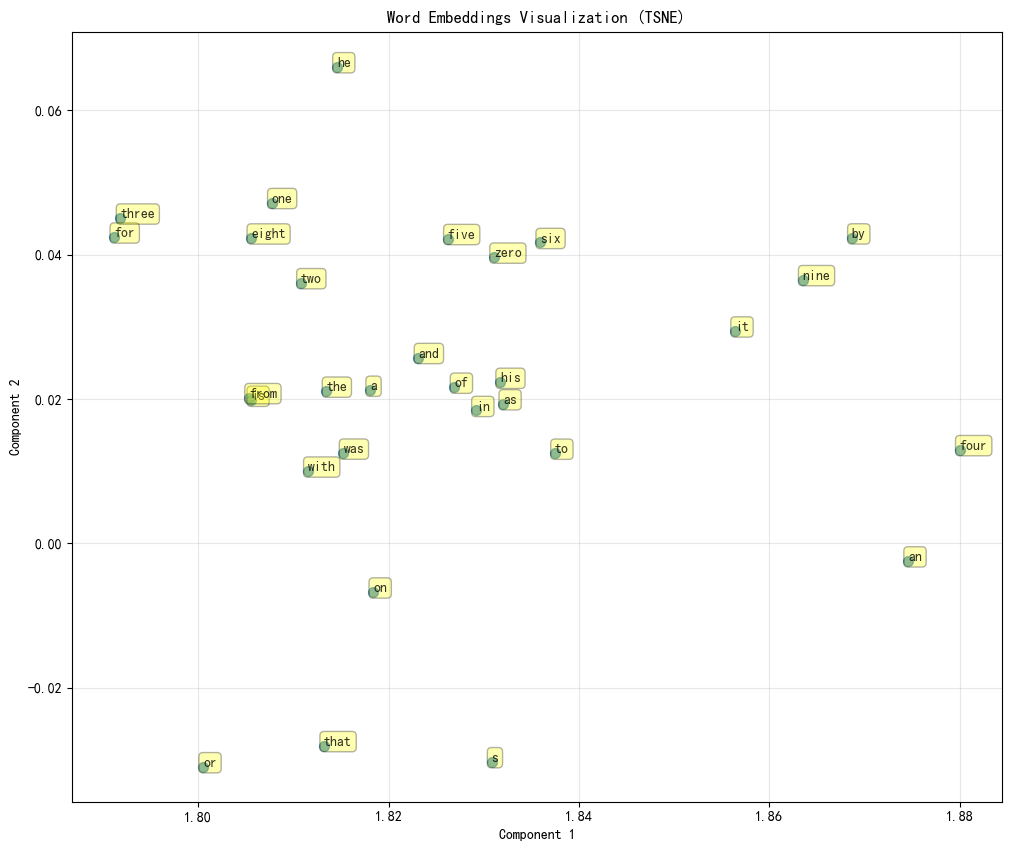

可视化结果已保存到: results/text/word_embeddings_tsne.png
正在使用PCA进行降维可视化...


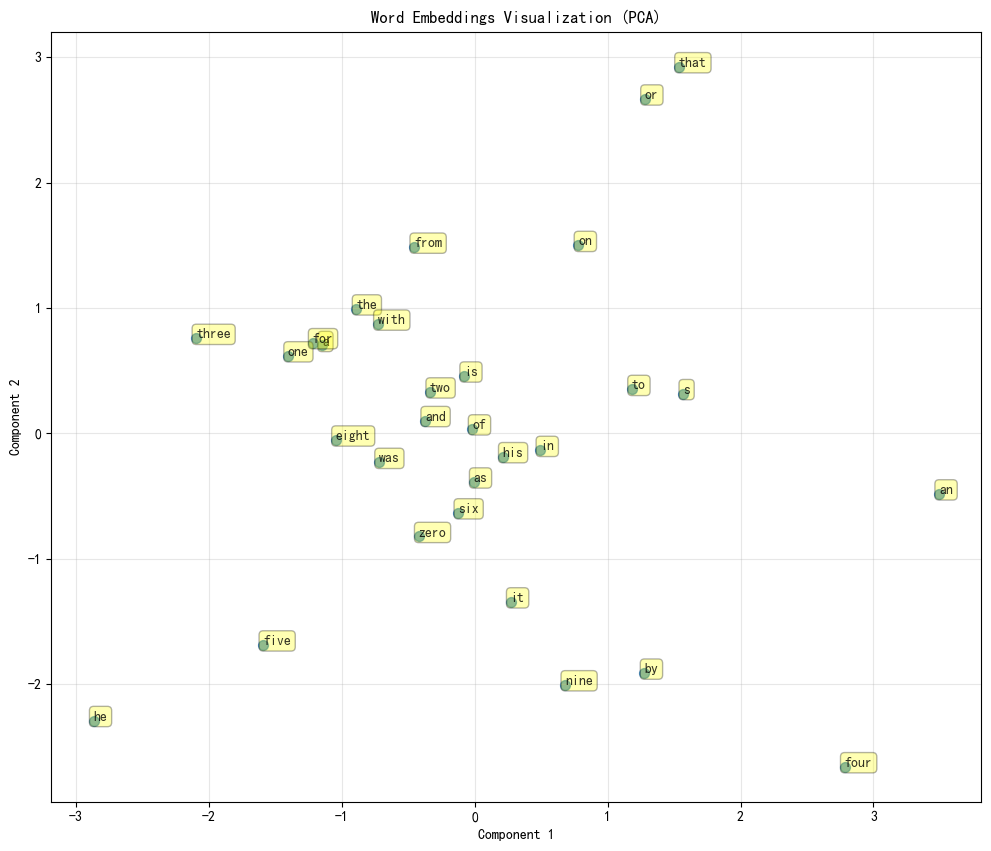

可视化结果已保存到: results/text/word_embeddings_pca.png

步骤8: 保存结果
所有结果已保存到 results/text/ 目录

所有任务完成！
词汇表大小: 3654
词向量维度: (3654, 50)
结果保存在: results/text/
使用自定义数据集运行...
文本数据处理与词向量训练

步骤1: 加载数据集
加载自定义数据失败: [Errno 2] No such file or directory: './ccmt2019.txt'
正在下载text8数据集...
数据集加载完成，长度: 500000

步骤2: 文本预处理
预处理完成，清理后文本长度: 500000

步骤3: 构建词汇表
词汇表构建完成，词汇数量: 3654

前10个最常出现的词:
  1. 'the': 出现5022次
  2. 'of': 出现3047次
  3. 'and': 出现2369次
  4. 'in': 出现1913次
  5. 'to': 出现1804次
  6. 'one': 出现1632次
  7. 'a': 出现1511次
  8. 'is': 出现1099次
  9. 'that': 出现797次
  10. 'zero': 出现764次

步骤4: 转换为ID序列
ID序列转换完成，序列长度: 74437，未知词数量: 8713

步骤5: 二次采样处理
二次采样完成，原始序列长度: 74437, 采样后: 10042

步骤6: 训练Skip-gram模型
开始训练Skip-gram模型...
词汇表大小: 3654
训练样本数: 60240
词向量维度: 50
Epoch: 1/10, Batch: 100, Loss: 5.7442
Epoch: 1/10, Batch: 200, Loss: 5.7358
Epoch: 1/10, Batch: 300, Loss: 5.7116
Epoch: 1/10, Batch: 400, Loss: 5.6740
Epoch: 1/10, Batch: 500, Loss: 5.6381
Epoch: 1/10, Batch: 600, Loss: 5.6189
Epoch: 1/10, Batch: 700, Loss: 5.5823
Epoch: 1/1

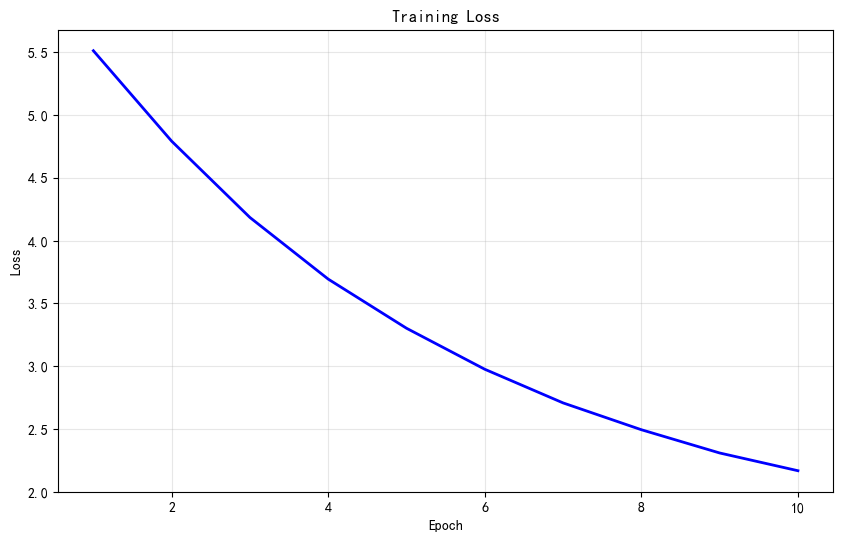


步骤7: 可视化词向量
正在使用TSNE进行降维可视化...


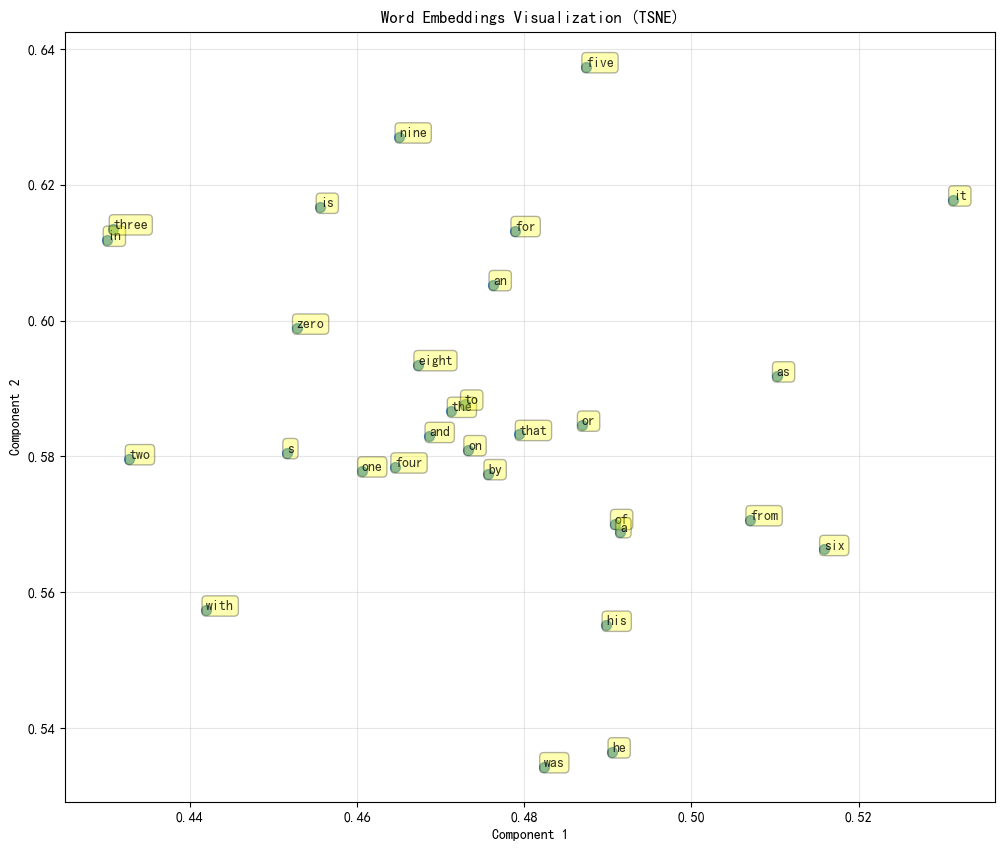

可视化结果已保存到: results/text/word_embeddings_tsne.png
正在使用PCA进行降维可视化...


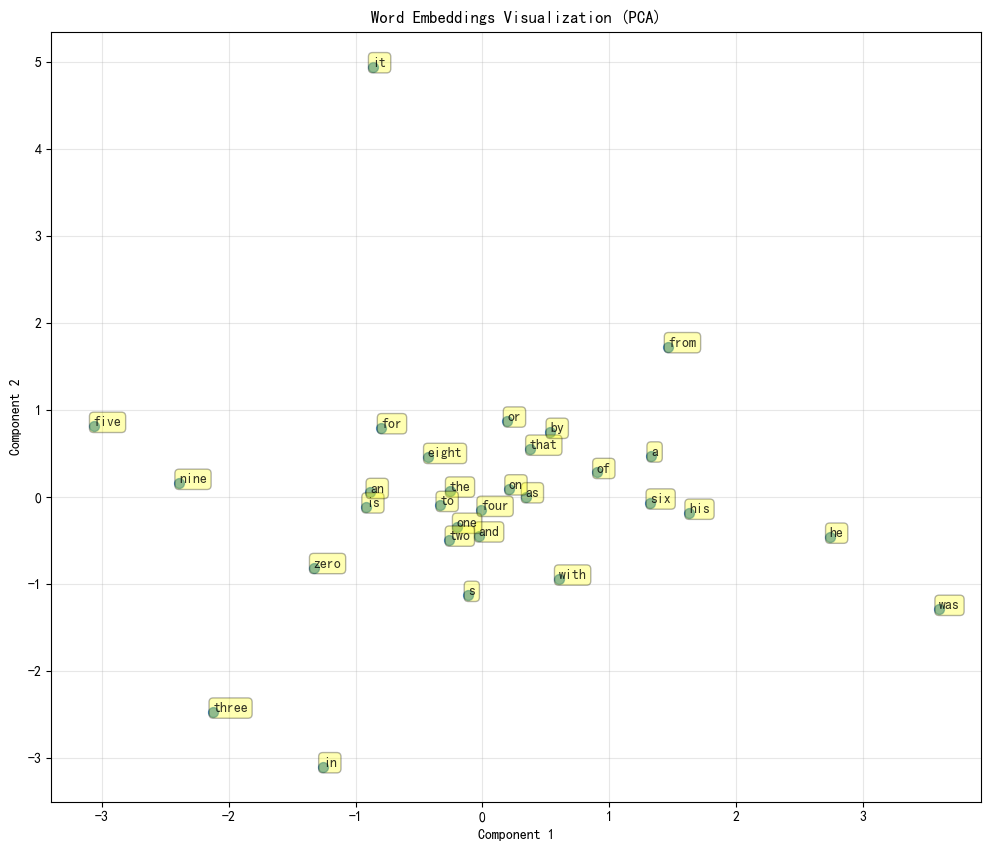

可视化结果已保存到: results/text/word_embeddings_pca.png

步骤8: 保存结果
所有结果已保存到 results/text/ 目录

所有任务完成！
词汇表大小: 3654
词向量维度: (3654, 50)
结果保存在: results/text/


In [4]:
# %% [markdown]
# # 文本数据处理与词向量训练
# 完整实现文本预处理、词汇表构建、Skip-gram训练和可视化

# %%
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import requests
import zipfile
import json

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建结果保存目录
os.makedirs('results/text', exist_ok=True)
print("目录创建完成")

# %%
class TextProcessor:
    """文本处理器类"""
    
    def __init__(self):
        self.word_to_id = {}
        self.id_to_word = {}
        self.word_freq = {}
        
    def load_text8_data(self):
        """加载text8数据集"""
        print("正在下载text8数据集...")
        url = "http://mattmahoney.net/dc/text8.zip"
        
        try:
            response = requests.get(url, stream=True, timeout=30)
            response.raise_for_status()
            
            with open("text8.zip", "wb") as f:
                for chunk in response.iter_content(chunk_size=1024):
                    if chunk:
                        f.write(chunk)
            
            # 解压文件
            with zipfile.ZipFile("text8.zip", 'r') as zip_ref:
                zip_ref.extractall(".")
            
            # 读取数据（使用部分数据以加快处理速度）
            with open("text8", "r", encoding="utf-8") as f:
                text = f.read()[:500000]  # 使用前50万个字符
            
            print(f"数据集加载完成，长度: {len(text)}")
            return text
            
        except Exception as e:
            print(f"下载数据集失败: {e}")
            # 创建示例数据
            print("使用示例数据继续运行...")
            return self.create_sample_data()
    
    def create_sample_data(self):
        """创建示例文本数据"""
        sample_text = """
        natural language processing is a field of computer science artificial intelligence 
        and linguistics concerned with the interactions between computers and human natural 
        languages deep learning models like word2vec are used to represent words as vectors 
        these vectors capture semantic meaning and can be used for various nlp tasks
        machine learning algorithms learn from data and improve their performance over time
        neural networks are inspired by the human brain and consist of interconnected nodes
        """
        return sample_text * 100  # 重复多次以增加数据量
    
    def load_custom_data(self, file_path):
        """加载自定义数据集"""
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                text = f.read()
            print(f"自定义数据集加载完成，长度: {len(text)}")
            return text
        except Exception as e:
            print(f"加载自定义数据失败: {e}")
            return self.load_text8_data()
    
    def preprocess_text(self, text):
        """
        文本预处理
        1. 去除标点符号
        2. 转换为小写
        """
        # 去除标点符号，只保留字母、数字和空格
        text_clean = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        
        # 转换为小写
        text_lower = text_clean.lower()
        
        print(f"预处理完成，清理后文本长度: {len(text_lower)}")
        return text_lower
    
    def build_vocabulary(self, text):
        """
        构建词汇表
        统计词频并为每个词分配唯一ID
        """
        # 分词
        words = text.split()
        
        # 统计词频
        word_counts = Counter(words)
        
        # 只保留出现次数大于3的词（减少词汇表大小）
        min_count = 3
        filtered_words = {word: count for word, count in word_counts.items() 
                         if count >= min_count}
        
        # 按词频排序
        sorted_words = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)
        
        # 构建词汇表映射
        self.word_to_id = {}
        self.id_to_word = {}
        self.word_freq = {}
        
        # 为每个词分配ID
        for idx, (word, freq) in enumerate(sorted_words):
            self.word_to_id[word] = idx
            self.id_to_word[idx] = word
            self.word_freq[word] = freq
        
        print(f"词汇表构建完成，词汇数量: {len(self.word_to_id)}")
        return words
    
    def text_to_sequence(self, words):
        """将文本转换为ID序列"""
        sequence = []
        unknown_count = 0
        
        for word in words:
            if word in self.word_to_id:
                sequence.append(self.word_to_id[word])
            else:
                unknown_count += 1
        
        print(f"ID序列转换完成，序列长度: {len(sequence)}，未知词数量: {unknown_count}")
        return sequence
    
    def subsampling(self, sequence, threshold=1e-5):
        """
        二次采样算法
        减少高频词的采样频率
        """
        if not sequence:
            return sequence
            
        total_words = len(sequence)
        word_freqs = {}
        
        # 统计序列中每个词的频率
        for word_id in sequence:
            if word_id not in word_freqs:
                word_freqs[word_id] = 0
            word_freqs[word_id] += 1
        
        word_freqs = {word_id: count / total_words for word_id, count in word_freqs.items()}
        
        # 计算丢弃概率
        discard_probs = {}
        for word_id, freq in word_freqs.items():
            discard_probs[word_id] = 1 - np.sqrt(threshold / freq) if freq > threshold else 1.0
        
        # 应用二次采样
        subsampled_sequence = []
        for word_id in sequence:
            if word_id in discard_probs:
                if np.random.random() > discard_probs[word_id]:
                    subsampled_sequence.append(word_id)
        
        print(f"二次采样完成，原始序列长度: {len(sequence)}, 采样后: {len(subsampled_sequence)}")
        return subsampled_sequence

# %%
class SkipGramDataset(Dataset):
    """Skip-gram模型数据集类"""
    
    def __init__(self, sequence, window_size=3):
        self.data = []
        
        # 为每个中心词创建训练样本
        for center_idx in range(len(sequence)):
            center_word = sequence[center_idx]
            
            # 获取上下文窗口
            start = max(0, center_idx - window_size)
            end = min(len(sequence), center_idx + window_size + 1)
            
            for context_idx in range(start, end):
                if context_idx != center_idx:
                    context_word = sequence[context_idx]
                    self.data.append((center_word, context_word))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        center_word, context_word = self.data[idx]
        return torch.tensor(center_word, dtype=torch.long), torch.tensor(context_word, dtype=torch.long)

# %%
class SkipGramModel(nn.Module):
    """Skip-gram模型"""
    
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # 中心词和上下文词共享嵌入层
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        
    def forward(self, center_words, context_words):
        center_vectors = self.embeddings(center_words)
        context_vectors = self.embeddings(context_words)
        
        # 计算点积得分
        scores = torch.sum(center_vectors * context_vectors, dim=1)
        
        return scores
    
    def get_word_vectors(self):
        """获取训练好的词向量"""
        return self.embeddings.weight.data.cpu().numpy()

# %%
def train_skipgram(sequence, word_to_id, embedding_dim=50, epochs=10, batch_size=64, window_size=3):
    """训练Skip-gram模型"""
    
    vocab_size = len(word_to_id)
    
    if vocab_size == 0:
        print("词汇表为空，无法训练模型")
        return None, None
    
    # 创建数据集和数据加载器
    dataset = SkipGramDataset(sequence, window_size=window_size)
    
    if len(dataset) == 0:
        print("训练数据为空，无法训练模型")
        return None, None
        
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # 初始化模型
    model = SkipGramModel(vocab_size, embedding_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"开始训练Skip-gram模型...")
    print(f"词汇表大小: {vocab_size}")
    print(f"训练样本数: {len(dataset)}")
    print(f"词向量维度: {embedding_dim}")
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        batch_count = 0
        
        for batch_idx, (center_words, context_words) in enumerate(dataloader):
            optimizer.zero_grad()
            
            # 正样本得分
            positive_scores = model(center_words, context_words)
            
            # 负采样 - 随机选择负样本
            negative_words = torch.randint(0, vocab_size, (center_words.shape[0] * 3,))
            negative_scores = model(center_words.repeat(3), negative_words)
            
            # 使用二元交叉熵损失
            positive_loss = torch.log(torch.sigmoid(positive_scores)).mean()
            negative_loss = torch.log(torch.sigmoid(-negative_scores)).mean()
            
            loss = -(positive_loss + negative_loss)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            batch_count += 1
            
            if batch_idx % 100 == 0 and batch_idx > 0:
                avg_loss = total_loss / batch_count
                print(f'Epoch: {epoch+1}/{epochs}, Batch: {batch_idx}, Loss: {avg_loss:.4f}')
        
        avg_epoch_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0
        losses.append(avg_epoch_loss)
        print(f'Epoch: {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}')
    
    # 绘制损失曲线
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs+1), losses, 'b-', linewidth=2)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.savefig('results/text/training_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 获取词向量
    word_vectors = model.get_word_vectors()
    
    return word_vectors, model

# %%
def visualize_vectors(word_vectors, id_to_word, method='tsne', top_n=50):
    """
    可视化词向量
    method: 'tsne' 或 'pca'
    top_n: 只显示前n个最常见的词
    """
    
    if len(word_vectors) == 0:
        print("词向量为空，无法可视化")
        return None
    
    # 只可视化前top_n个词
    if len(word_vectors) > top_n:
        word_vectors_subset = word_vectors[:top_n]
        words_to_show = [id_to_word[i] for i in range(top_n)]
    else:
        word_vectors_subset = word_vectors
        words_to_show = [id_to_word[i] for i in range(len(word_vectors))]
    
    print(f"正在使用{method.upper()}进行降维可视化...")
    
    if method.lower() == 'tsne':
        # 使用t-SNE降维
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(word_vectors_subset)-1))
        vectors_2d = tsne.fit_transform(word_vectors_subset)
    else:
        # 使用PCA降维
        pca = PCA(n_components=2, random_state=42)
        vectors_2d = pca.fit_transform(word_vectors_subset)
    
    # 创建可视化
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.7, s=50)
    
    # 添加词标签
    for i, word in enumerate(words_to_show):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                    fontsize=10, alpha=0.8,
                    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
    
    plt.title(f'Word Embeddings Visualization ({method.upper()})')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, alpha=0.3)
    
    # 保存图像
    save_path = f'results/text/word_embeddings_{method}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"可视化结果已保存到: {save_path}")
    
    return vectors_2d

# %%
def save_results(word_vectors, word_to_id, processor, sequence):
    """保存训练结果"""
    
    # 保存词向量
    np.save('results/text/word_vectors.npy', word_vectors)
    
    # 保存词汇表
    vocab_data = {
        'word_to_id': processor.word_to_id,
        'id_to_word': processor.id_to_word,
        'word_freq': processor.word_freq
    }
    
    with open('results/text/vocabulary.json', 'w', encoding='utf-8') as f:
        json.dump(vocab_data, f, indent=2, ensure_ascii=False)
    
    # 保存词向量为文本格式
    with open('results/text/word_vectors.txt', 'w', encoding='utf-8') as f:
        f.write(f"{len(word_vectors)} {word_vectors.shape[1]}\n")
        for word, word_id in word_to_id.items():
            if word_id < len(word_vectors):
                vector_str = ' '.join([f"{x:.6f}" for x in word_vectors[word_id]])
                f.write(f"{word} {vector_str}\n")
    
    # 保存处理统计信息
    stats = {
        "vocab_size": len(word_to_id),
        "sequence_length": len(sequence),
        "embedding_dim": word_vectors.shape[1],
        "most_common_words": list(processor.word_to_id.keys())[:10]
    }
    
    with open('results/text/processing_stats.json', 'w', encoding='utf-8') as f:
        json.dump(stats, f, indent=2, ensure_ascii=False)
    
    print("所有结果已保存到 results/text/ 目录")

# %%
def main(use_custom_data=False, custom_file_path=None):
    """主函数"""
    
    print("=" * 60)
    print("文本数据处理与词向量训练")
    print("=" * 60)
    
    # 初始化文本处理器
    processor = TextProcessor()
    
    # 1. 加载数据集
    print("\n步骤1: 加载数据集")
    if use_custom_data and custom_file_path:
        text = processor.load_custom_data(custom_file_path)
    else:
        text = processor.load_text8_data()
    
    # 2. 预处理文本
    print("\n步骤2: 文本预处理")
    processed_text = processor.preprocess_text(text)
    
    # 3. 构建词汇表
    print("\n步骤3: 构建词汇表")
    words = processor.build_vocabulary(processed_text)
    
    # 显示前10个最常出现的词
    print("\n前10个最常出现的词:")
    for i, (word, word_id) in enumerate(list(processor.word_to_id.items())[:10]):
        freq = processor.word_freq[word]
        print(f"  {i+1}. '{word}': 出现{freq}次")
    
    # 4. 转换为ID序列
    print("\n步骤4: 转换为ID序列")
    sequence = processor.text_to_sequence(words)
    
    # 5. 二次采样
    print("\n步骤5: 二次采样处理")
    subsampled_sequence = processor.subsampling(sequence)
    
    # 6. 训练Skip-gram模型
    print("\n步骤6: 训练Skip-gram模型")
    word_vectors, model = train_skipgram(
        subsampled_sequence, 
        processor.word_to_id,
        embedding_dim=50,  # 减小维度以加快训练
        epochs=10,
        batch_size=64,
        window_size=3
    )
    
    if word_vectors is not None and model is not None:
        # 7. 可视化词向量
        print("\n步骤7: 可视化词向量")
        
        # 使用t-SNE可视化
        vectors_2d_tsne = visualize_vectors(
            word_vectors, 
            processor.id_to_word, 
            method='tsne',
            top_n=30  # 只显示前30个词
        )
        
        # 使用PCA可视化
        vectors_2d_pca = visualize_vectors(
            word_vectors, 
            processor.id_to_word, 
            method='pca',
            top_n=30  # 只显示前30个词
        )
        
        # 保存结果
        print("\n步骤8: 保存结果")
        save_results(word_vectors, processor.word_to_id, processor, subsampled_sequence)
        
        print("\n" + "=" * 60)
        print("所有任务完成！")
        print(f"词汇表大小: {len(processor.word_to_id)}")
        print(f"词向量维度: {word_vectors.shape}")
        print(f"结果保存在: results/text/")
    else:
        print("训练失败，请检查数据")

# %%
# 运行主程序 - 使用text8数据集
print("使用text8数据集运行...")
main(use_custom_data=False)

# %%
print("使用自定义数据集运行...")
main(use_custom_data=True, custom_file_path="./ccmt2019.txt")

In [3]:
import sys
!{sys.executable} -m pip install requests torch scikit-learn matplotlib numpy -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/7c/e4/56027c4a6b4ae70ca9de302488c5ca95ad4a39e190093d6c1a8ace08341b/requests-2.32.4-py3-none-any.whl (64 kB)
